C:\Users\Utente\AppData\Local\Temp\ipykernel_2952\1072871159.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data= pd.read_csv('rough_1D_chain.txt', skiprows=0, delim_whitespace=True)
C:\Users\Utente\AppData\Local\Temp\ipykernel_2952\1072871159.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


    1.00  5.33978860
0   1.25   -1.977672
1   1.50   -4.890080
2   1.75   -5.915352
3   2.00   -6.135077
4   2.25   -5.941810
5   2.50   -5.539716
6   2.75   -5.041904
7   3.00   -4.523557
8   3.25   -4.016642
9   3.50   -3.546802
10  3.75   -3.117205
11  4.00   -2.723546


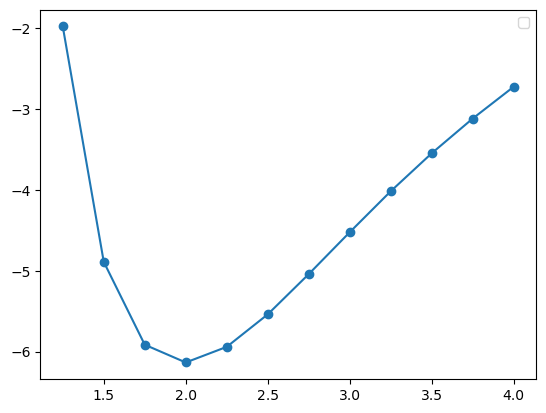

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt

data= pd.read_csv('rough_1D_chain.txt', skiprows=0, delim_whitespace=True)

print (data)
d= data.iloc[:,0]
E_g=data.iloc[:,1]

#def parab(x, a,b,c):
 #   return a*x**2 + b*x + c
#fit = opt.curve_fit(parab, d.iloc[3:7], E_g.iloc[3:7], p0=[1,1,100])
#popv, pcov = fit

#min= opt.minimize(parab, x0=0, args=tuple(popv))
#print("Minimum at d =", min.x, "with E_g =", parab(min.x, *popv))
#print ("Fitted parameters:", popv)
plt.plot( d,  E_g, marker='o', linestyle='-')
#Splt.plot( x, parab(x, *popv), linestyle='-', label='fit')
plt.legend()
plt.show()



C:\Users\Utente\AppData\Local\Temp\ipykernel_2952\782578818.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data= pd.read_csv('Kval_1D_chain.txt', skiprows=0, delim_whitespace=True)


    Kpoints       E_g
0         3 -6.648412
1         4 -6.350885
2         5 -6.213046
3         6 -6.135086
4         7 -6.088275
5         8 -6.056497
6         9 -6.038431
7        10 -6.023151
8        11 -6.014398
9        12 -6.006068
10       13 -5.998276
11       14 -5.992483
12       15 -5.990803
13       16 -5.986291
14       17 -5.984642
15       18 -5.980483
16       19 -5.978501
17       20 -5.978226
18       21 -5.974780
19       22 -5.974424
20       23 -5.973363
21       24 -5.972848
22       25 -5.972562
23       26 -5.970928
24       27 -5.970728
25       28 -5.969428
26       29 -5.968038
27       30 -5.968240


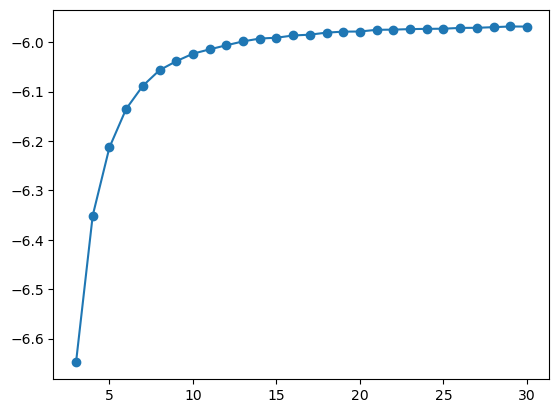

Converged K-point at 14
With gap = 0.0016801900000000813


In [32]:
##### Sweeep over the K ponts from 3 to 30
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data= pd.read_csv('Kval_1D_chain.txt', skiprows=0, delim_whitespace=True)

data.sort_values(by=['Kpoints'], inplace=True)
data.reset_index(drop=True, inplace=True)
print (data)
Kp= data.iloc[:,0]
E_g=data.iloc[:,1]
plt.plot( Kp,  E_g, marker='o', linestyle='-')
#plt.legend()
plt.show()


def conv(Kp, Eg):
    conv_dE=2e-3
    E0  = Eg[1]  ### initial gap
    for E in Eg:        
        if np.abs( E- E0) < conv_dE: ### k point corresponds to i-i index
            index=pd.Index(Eg).get_loc(E0)
            print("Converged K-point at", Kp[index])
            print("With gap =", E-E0)   
            break
        else: 
            E0=E
conv(Kp, E_g) 




C:\Users\Utente\AppData\Local\Temp\ipykernel_2952\688621325.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data= pd.read_csv('Opt_1D_chain_K14.txt', skiprows=0, delim_whitespace=True)


   A_lat       E_g
0   1.80 -5.830761
1   1.85 -5.904235
2   1.90 -5.951776
3   1.95 -5.980397
4   2.00 -5.992483
5   2.05 -5.988544
6   2.10 -5.964898
7   2.15 -5.929874
8   2.20 -5.887809
Minimum at lat par = [2.016983] with E_g = [-5.99324285]
Interatomic Distance: [1.0084915]


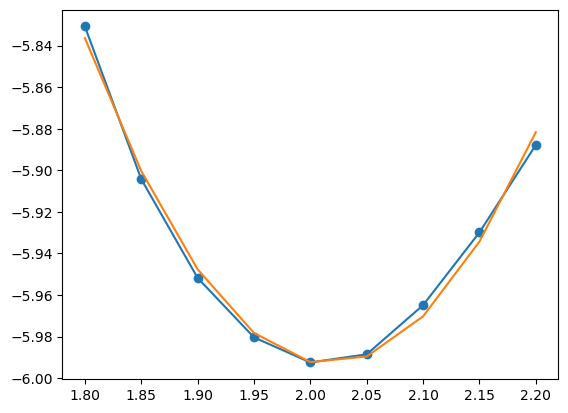

In [37]:
#### opt values for k = 14 so then E ###
import pandas as pd
import matplotlib.pyplot as plt

data= pd.read_csv('Opt_1D_chain_K14.txt', skiprows=0, delim_whitespace=True)

print (data)
A_lat= data.iloc[:,0]
E_g=data.iloc[:,1]

def parab(x, a,b,c):
  return a*x**2 + b*x + c
fit = opt.curve_fit(parab, A_lat, E_g, p0=[1,1,-5])
popv, pcov = fit

min= opt.minimize(parab, x0=0, args=tuple(popv))

print("Minimum at lat par =", min.x, "with E_g =", parab(min.x, *popv))
print ("Interatomic Distance:", min.x / 2)
plt.plot( A_lat,  E_g, marker='o', linestyle='-')
plt.plot( A_lat, parab(A_lat, *popv), linestyle='-', label='fit')

#plt.legend()
plt.show()


C:\Users\Utente\AppData\Local\Temp\ipykernel_2952\16659163.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data= pd.read_csv('Pert_1D.txt', skiprows=0, delim_whitespace=True)


    Int_A0       E_g
0     0.50 -4.352024
1     0.55 -5.290634
2     0.60 -5.862421
3     0.65 -6.181414
4     0.70 -6.327788
5     0.75 -6.358555
6     0.80 -6.314983
7     0.85 -6.228778
8     0.90 -6.126678
9     0.95 -6.036650
10    1.00 -5.991706
Minimum at Interatomic Distance = [0.74771566] with E_g = [-6.36484398]


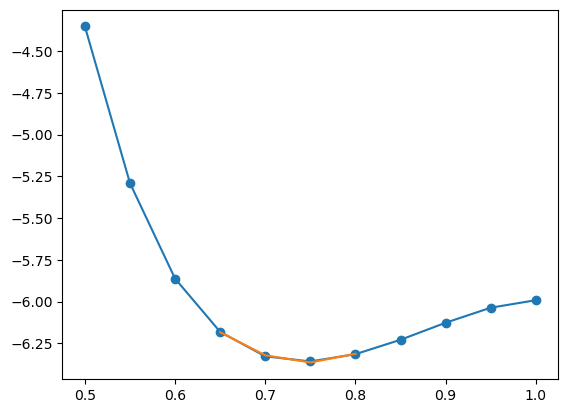

In [42]:
#### opt values for k = 14 so then E ###
import pandas as pd
import matplotlib.pyplot as plt

data= pd.read_csv('Pert_1D.txt', skiprows=0, delim_whitespace=True)

print (data)
A_lat= data.iloc[:,0]
E_g=data.iloc[:,1]

def parab(x, a,b,c):
  return a*x**2 + b*x + c
fit = opt.curve_fit(parab, A_lat[3:7], E_g[3:7], p0=[1,1,10])
popv, pcov = fit

min= opt.minimize(parab, x0=0, args=tuple(popv))

print("Minimum at Interatomic Distance =", min.x, "with E_g =", parab(min.x, *popv))

plt.plot( A_lat,  E_g, marker='o', linestyle='-')
plt.plot( A_lat[3:7], parab(A_lat[3:7], *popv), linestyle='-', label='fit')
#plt.legend()
plt.show()


C:\Users\Utente\AppData\Local\Temp\ipykernel_16256\1298131917.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data= pd.read_csv('BAND.dat', skiprows=3, delim_whitespace=True)


     0.00000  -7.236708
0    0.12715  -7.178194
1    0.25430  -7.009125
2    0.38145  -6.723463
3    0.50860  -6.327692
4    0.63574  -5.822977
..       ...        ...
247  5.72170   8.142574
248  5.84884   7.711407
249  5.97599   7.403431
250  6.10314   7.218645
251  6.23029   7.157050

[252 rows x 2 columns]


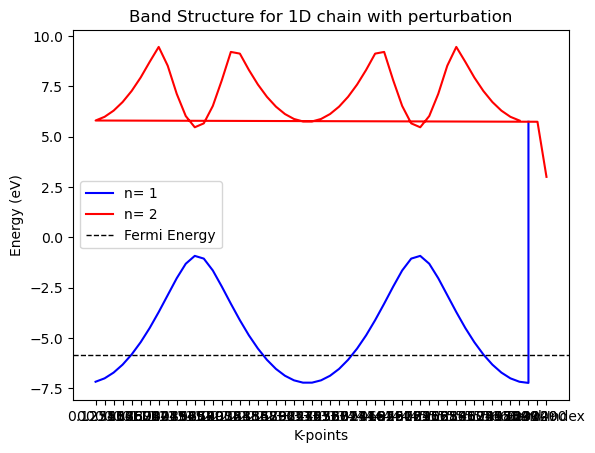

In [ ]:
##### Band structure over the pert 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data= pd.read_csv('BAND.dat', skiprows=3, delim_whitespace=True)
#data.sort_values(by=['N'], inplace=True)
#data.reset_index(drop=True, inplace=True)
print (data)

K1= data.iloc[:50,0]
#K1.sort_values(inplace=True)
#K1.reset_index(drop=True, inplace=True)

K2= data.iloc[50:100,0]
#K2.sort_values(inplace=True)
#K2.reset_index(drop=True, inplace=True)


Ek1=data.iloc[:50,1]
#Ek1.sort_values(inplace=True)
#Ek1.reset_index(drop=True, inplace=True)

Ek2=data.iloc[50:100,1]
#Ek2.sort_values(inplace=True)
#Ek2.reset_index(drop=True, inplace=True)

plt.plot( K1, Ek1 , linestyle='-', label='n= 1', color='blue')
plt.plot( K2, Ek2 , linestyle='-', label='n= 2', color='red')
plt.axhline(y=0 , color='black', linestyle='--', linewidth=1, label='Fermi Energy')
plt.xlabel('K-points')
plt.ylabel('Energy (eV)')   
plt.title('Band Structure for 1D chain with perturbation')
plt.legend()
plt.show()